#1) Import libraries

In [17]:
import tensorflow as tf
import numpy as np
%matplotlib inline
import cv2
import os

import matplotlib.pyplot as plt
from sklearn.utils import shuffle
import seaborn as sn; sn.set(font_scale=1.4)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.layers import MaxPooling2D, Conv2D
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import Dense

#2) Get Data

In [2]:
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()  # load data fron tf

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 241s 1us/step


In [3]:
train_images, train_labels = shuffle(train_images, train_labels, random_state=25)

In [4]:
print(f"X_train shape: {train_images.shape}")
print(f"X_test shape: {test_images.shape}")

X_train shape: (50000, 32, 32, 3)
X_test shape: (10000, 32, 32, 3)


In [5]:
# Normalize pixel values to be between 0 and 1
train_images, test_images = train_images / 255.0, test_images / 255.0

In [6]:
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']
class_names_label = {class_name:i for i, class_name in enumerate(class_names)}

nb_classes = len(class_names)

class_names_label


{'airplane': 0,
 'automobile': 1,
 'bird': 2,
 'cat': 3,
 'deer': 4,
 'dog': 5,
 'frog': 6,
 'horse': 7,
 'ship': 8,
 'truck': 9}

In [7]:
def display_random_image(class_names, images, labels):
    """
        Display a random image from the images array and its correspond label from the labels array.
    """

    index = np.random.randint(images.shape[0])
    plt.figure()
    plt.imshow(images[index])
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.title('Image #{} : '.format(index) + class_names[labels[index][0]])
    plt.show()

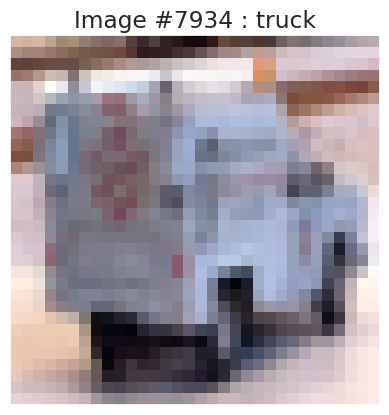

In [8]:
display_random_image(class_names, train_images, train_labels)

In [9]:
def display_examples(class_names, images, labels):
    """
        Display 25 images from the images array with its corresponding labels
    """

    fig = plt.figure(figsize=(10,10))
    fig.suptitle("Some examples of images of the dataset", fontsize=16)
    for i in range(25):
        plt.subplot(5,5,i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(images[i], cmap=plt.cm.binary)
        plt.xlabel(class_names[int(labels[i][0])])
    plt.show()

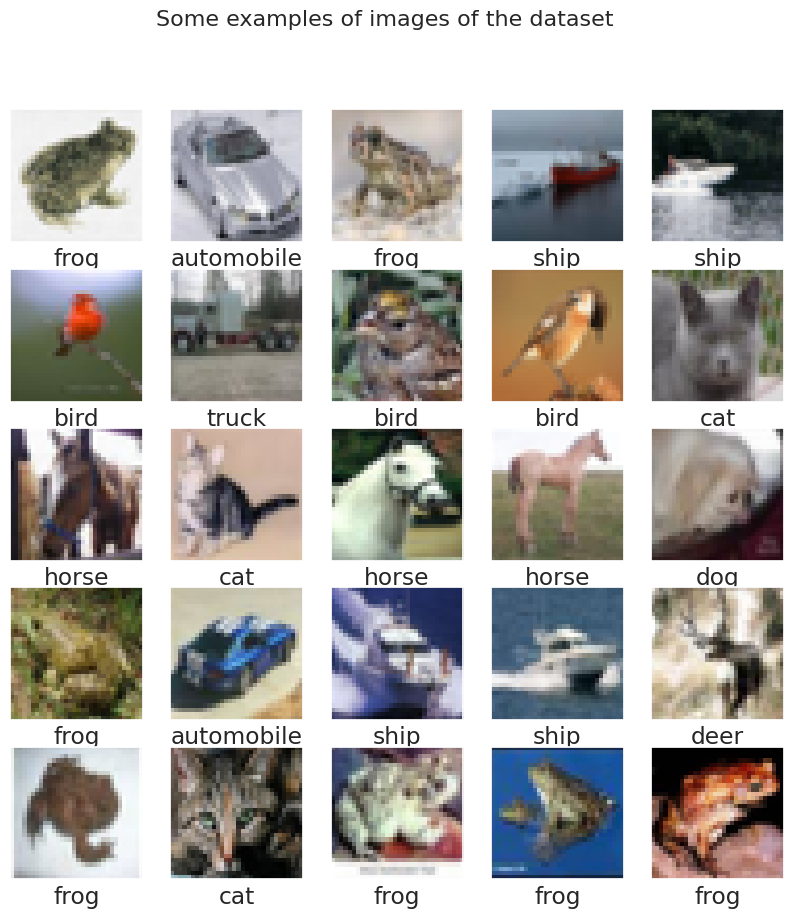

In [10]:
display_examples(class_names, train_images, train_labels)

## Data Augmentation

In [26]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1, 0.1)
])

## Transfer Learning

In [27]:
# apply pretrained model ResNet50V2

base_model = tf.keras.applications.ResNet50V2(
    include_top=False,
    weights='imagenet',
    input_shape=(96, 96, 3)
)
base_model.trainable = False

In [28]:
inputs = tf.keras.Input(shape=(32, 32, 3))
x = data_augmentation(inputs)              # 1) apply Augmentation
x = layers.UpSampling2D(size=(3, 3))(x)
x = base_model(x, training=False)          # 2)passing without upgrade BatchNormalization
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)

In [29]:
# 4. Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
history_phase1 = model.fit(
    train_images, train_labels,
    epochs=5,
    batch_size=64,
    validation_data=(test_images, test_labels)
)

Epoch 1/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 61s 62ms/step - accuracy: 0.4585 - loss: 1.6085 - val_accuracy: 0.6742 - val_loss: 0.9499
Epoch 2/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 64ms/step - accuracy: 0.5122 - loss: 1.3845 - val_accuracy: 0.6831 - val_loss: 0.9032
Epoch 3/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 49s 63ms/step - accuracy: 0.5226 - loss: 1.3484 - val_accuracy: 0.6943 - val_loss: 0.8810
Epoch 4/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 50s 63ms/step - accuracy: 0.5303 - loss: 1.3242 - val_accuracy: 0.6987 - val_loss: 0.8789
Epoch 5/5
782/782 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.5393 - loss: 1.3122 - val_accuracy: 0.7064 - val_loss: 0.8548


In [31]:
base_model.trainable = True
for layer in base_model.layers[:100]:
    layer.trainable = False

# 1. Compile with tiny Learning Rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 2. Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=2,
        min_lr=1e-7
    )
]

history_fine = model.fit(
    train_images, train_labels,
    epochs=15,
    batch_size=64,
    validation_data=(test_images, test_labels),
    callbacks=callbacks
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 130s 139ms/step - accuracy: 0.5076 - loss: 1.4082 - val_accuracy: 0.7080 - val_loss: 0.8554 - learning_rate: 1.0000e-05
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 106s 135ms/step - accuracy: 0.5846 - loss: 1.1952 - val_accuracy: 0.7464 - val_loss: 0.7429 - learning_rate: 1.0000e-05
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 133ms/step - accuracy: 0.6292 - loss: 1.0772 - val_accuracy: 0.7709 - val_loss: 0.6730 - learning_rate: 1.0000e-05
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 133ms/step - accuracy: 0.6553 - loss: 0.9978 - val_accuracy: 0.7855 - val_loss: 0.6259 - learning_rate: 1.0000e-05
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 132ms/step - accuracy: 0.6768 - loss: 0.9381 - val_accuracy: 0.7985 - val_loss: 0.5856 - learning_rate: 1.0000e-05
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 103s 132ms/step - accuracy: 0.6943 - loss: 0.8900 - val_accuracy: 0.8113 - val_loss: 0.5546 - learning_rate: 1.0000e-05
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 

In [32]:
# Fine-Tuning for anthor 15 Epochs
history_fine_2 = model.fit(
    train_images, train_labels,
    epochs=15,
    batch_size=64,
    validation_data=(test_images, test_labels),
    callbacks=callbacks
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 105s 134ms/step - accuracy: 0.7905 - loss: 0.6108 - val_accuracy: 0.8678 - val_loss: 0.3898 - learning_rate: 1.0000e-05
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 134ms/step - accuracy: 0.7945 - loss: 0.5984 - val_accuracy: 0.8703 - val_loss: 0.3838 - learning_rate: 1.0000e-05
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 132ms/step - accuracy: 0.8011 - loss: 0.5780 - val_accuracy: 0.8709 - val_loss: 0.3779 - learning_rate: 1.0000e-05
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 104s 132ms/step - accuracy: 0.8090 - loss: 0.5582 - val_accuracy: 0.8749 - val_loss: 0.3683 - learning_rate: 1.0000e-05
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 142s 133ms/step - accuracy: 0.8128 - loss: 0.5517 - val_accuracy: 0.8736 - val_loss: 0.3693 - learning_rate: 1.0000e-05
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 103s 132ms/step - accuracy: 0.8159 - loss: 0.5380 - val_accuracy: 0.8757 - val_loss: 0.3637 - learning_rate: 1.0000e-05
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 

##Note on Model Training:
If the validation loss is still decreasing after 30 epochs, you can resume training for additional epochs using initial_epoch to further improve model accuracy without re-training from scratch

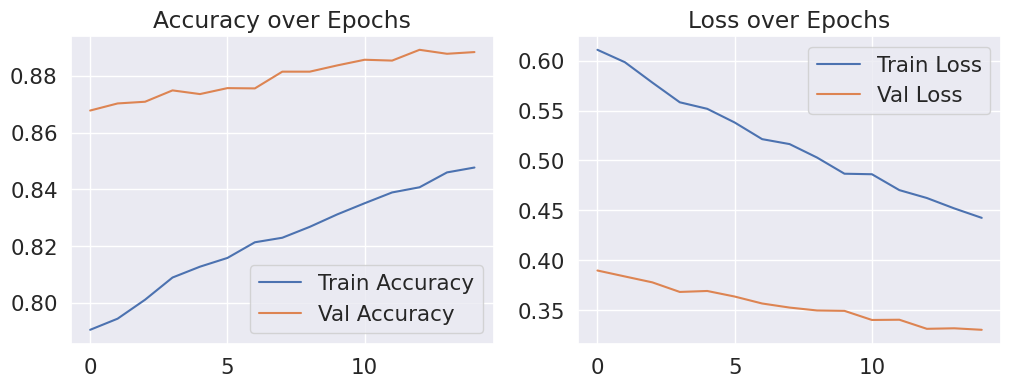

In [36]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_fine_2.history['accuracy'], label='Train Accuracy')
plt.plot(history_fine_2.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_fine_2.history['loss'], label='Train Loss')
plt.plot(history_fine_2.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()

In [37]:
# Save the model in native Keras format
model.save('cifar10_classifier_model.keras')